<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/ce/Logo-ITM-01.png/1200px-Logo-ITM-01.png" width="300" alt="cognitiveclass.ai logo"  />
</center>

# Notebook: Calories

## Objetivos

*   Predecir el número de calorías quemadas según los datos biometricos.
*   Asegurar la calidad y consistencia de las variables biométricas evitando de esta manera sesgos en el análisis y en los modelos predictivos.
*   Optimizar la estructura del dataset mediante la identificación y documentación de valores atípicos, asegurando que no afecten la interpretación posterior de los resultados.

## Tabla de Contenido

- [Introducción](#introducción)
- [Objetivos](#objetivos)
- [Carga de datos y exploración inicial](#carga-de-datos-y-exploración-inicial)
- [Limpieza y preprocesamiento](#limpieza-y-preprocesamiento)
- [Visualización de distribuciones](#visualización-de-distribuciones)
- [Detección y eliminación de outliers](#detección-y-eliminación-de-outliers)
- [Correlaciones y relaciones entre variables](#correlaciones-y-relaciones-entre-variables)
- [Conclusiones generales](#conclusiones-generales)


**Introducción**

Este notebook analiza y prepara una base de datos sintética que contiene variables biométricas asociadas al cálculo de calorías quemadas durante la actividad física. El objetivo es realizar un proceso de limpieza y preprocesamiento que garantice la calidad del dataset, identificando posibles inconsistencias, valores faltantes y outliers. Con ello se busca dejar los datos listos para su posterior análisis y modelado.

**Carga de datos y exploración inicial**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/drive/MyDrive/Proyecto AyP/Calories.csv"
bases= pd.read_csv(file_path)

bases.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [28]:
bases.shape

(750000, 9)

***Columnas***

id:identifica a cada persona, ayudando así, a diferenciarlas y a la organización de la base.

Sex:Categoriza el género del usuario y permite obtener mejores resultados, pues las diferencias fisiológicas inciden en calorias quemadas.

Age: Característica cuantitativa, La edad (en años) afecta el metabolismo, además el gasto energético del ser humano.

Height:Característica cuantitativa,La altura (en cm) influye en el índice de masa corporal (IMC) afectando indirectamente a la quema de energía del individuo.

Weight:Característica cuantitativa,El peso (en Kg) del usuario es un factor clave para la determinación del gasto caloríco.

Duration:Característica cuantitativa,La duración (en min) de la persona haciendo ejercicio es una claro determinante del gasto enérgetico.

Heart_Rate:Característica cuantitativa, La frecuencia cardiaca presentada durante la práctica (en lpm) refleja el esfuerzo físico.

Body_Temp:Característica cuantitativa, La temperatura corporal (° celsius) durante la actividad puede señalar la tasa metabólica o la respuesta fisiológica al esfuerzo físico.

Calories:Es la predicción de cuantas calorias va a quemar el usuario con relación las caracteristicas biométricas.

In [29]:
bases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [30]:
bases.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [31]:
bases.head(9)

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
5,5,female,26,156.0,56.0,19.0,100.0,40.5,103.0
6,6,female,21,172.0,73.0,3.0,81.0,38.3,9.0
7,7,male,46,188.0,94.0,23.0,100.0,40.8,145.0
8,8,female,33,166.0,63.0,25.0,107.0,40.5,161.0


**Limpieza y preprocesamiento**

In [32]:
bases.isnull().sum()

,0
id,0
Sex,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [33]:
bases.duplicated().sum()

np.int64(0)

La base de datos no contenia datos nulos ni duplicados.

**Visualización de distribuciones**

> Se crearon gráficos como histrogramas y de barras para evidenciar la distribución de datos.



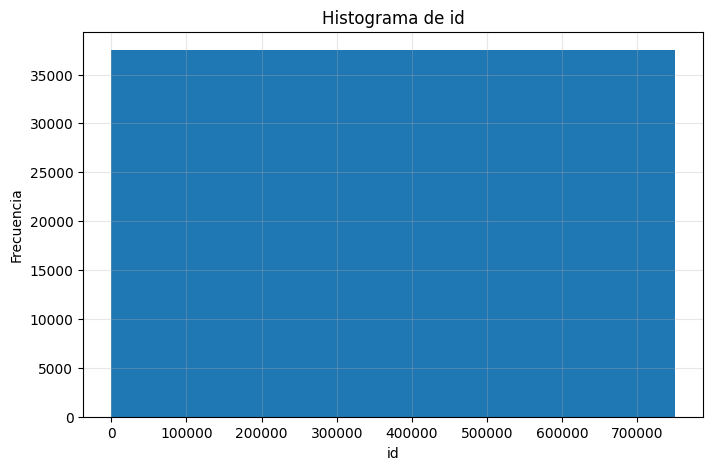

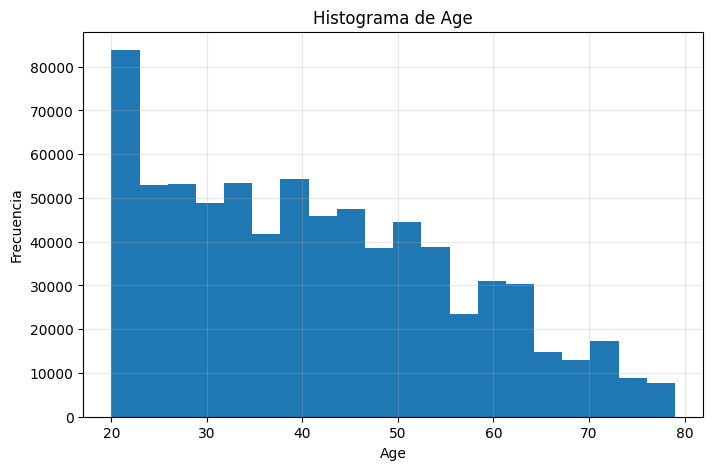

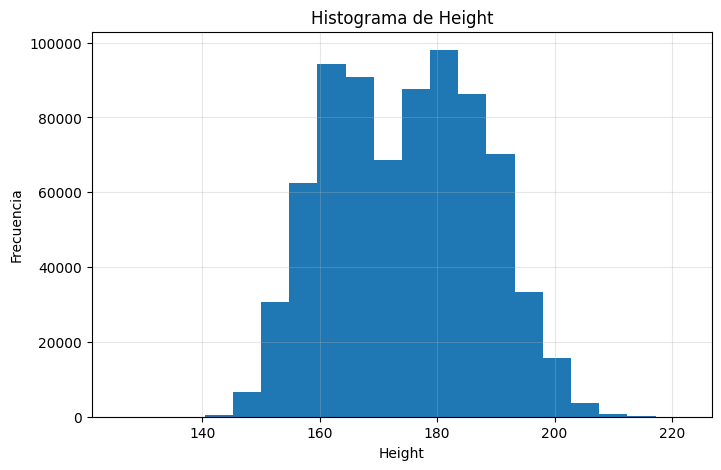

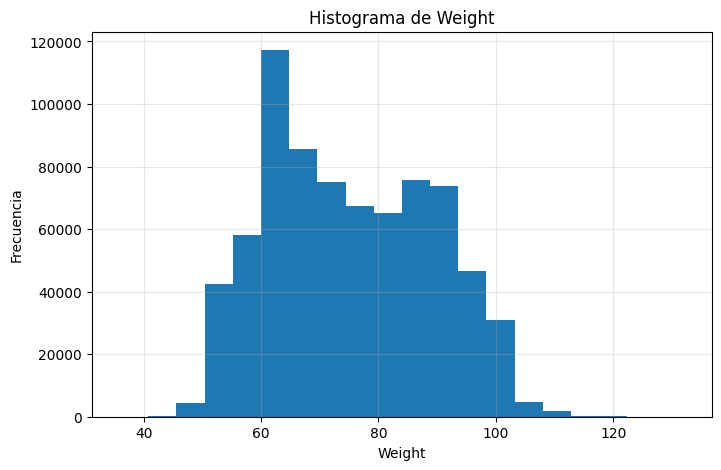

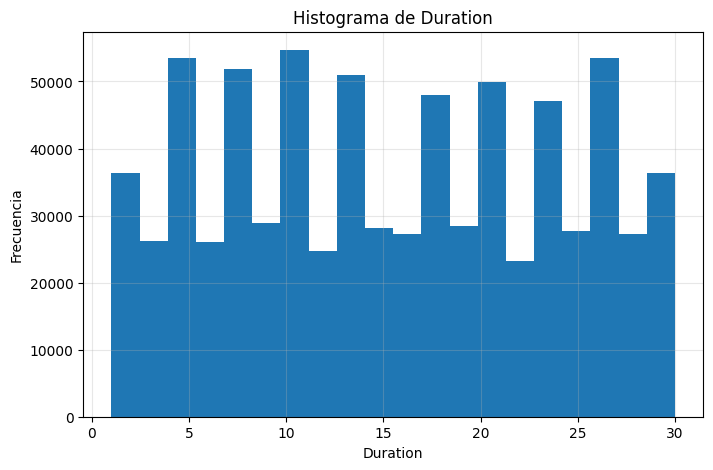

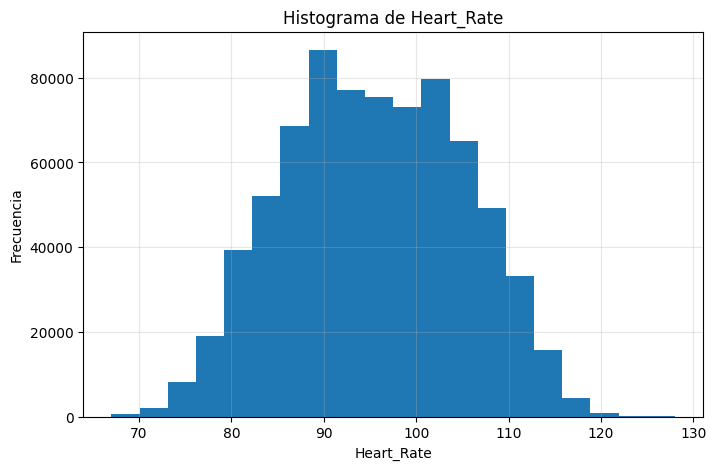

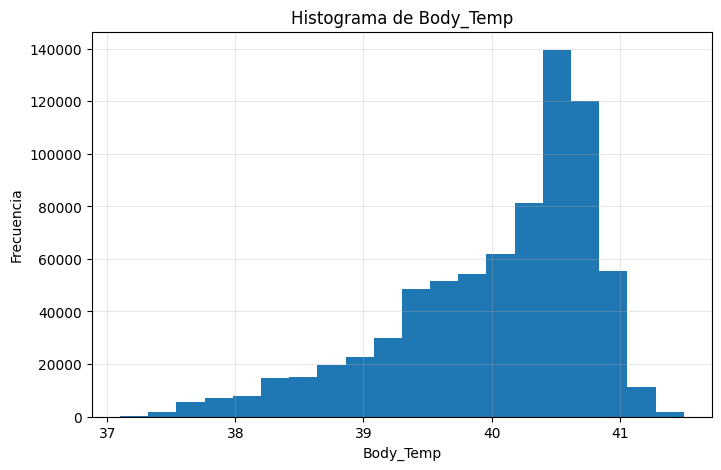

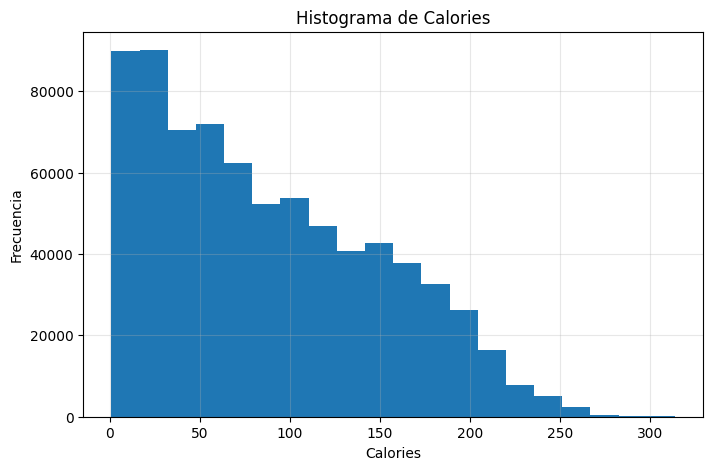

In [34]:
numeric_cols = bases.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plt.hist(bases[col], bins=20)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {col}')
    plt.grid(True, alpha=0.3)
    plt.show()



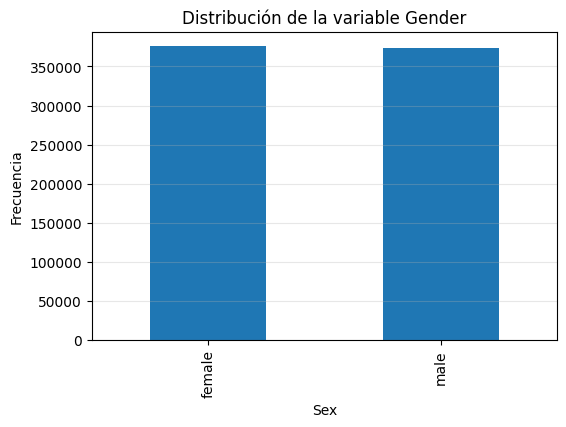

In [35]:
plt.figure(figsize=(6,4))
bases['Sex'].value_counts().plot(kind='bar')
plt.xlabel('Sex')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable Gender')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [36]:
bases['Sex'].value_counts()

,count
Sex,
female,375721
male,374279


**Detección y eliminación de outliers**

> Agregar bloque entrecomillado



Se aplicó la técnica del rango intercuartílico (IQR) para detectar datos átipicos en todas las variables numéricas.

In [37]:
num_cols = bases.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    Q1 = bases[col].quantile(0.25)
    Q3 = bases[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    bases = bases[(bases[col] >= lim_inf) & (bases[col] <= lim_sup)]


In [38]:
bases.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734886 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          734886 non-null  int64  
 1   Sex         734886 non-null  object 
 2   Age         734886 non-null  int64  
 3   Height      734886 non-null  float64
 4   Weight      734886 non-null  float64
 5   Duration    734886 non-null  float64
 6   Heart_Rate  734886 non-null  float64
 7   Body_Temp   734886 non-null  float64
 8   Calories    734886 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 56.1+ MB


Se eliminaron 15114 datos del data set

**Correlaciones y relaciones entre variables**

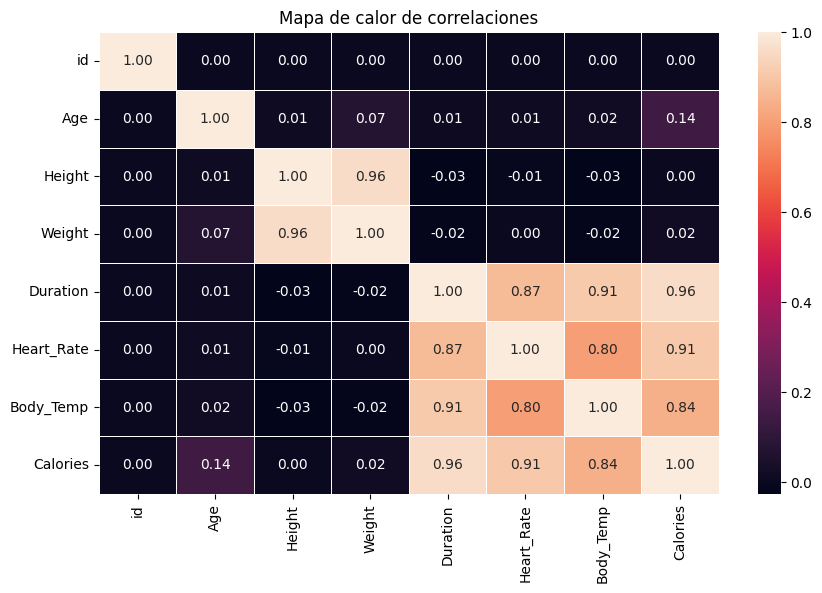

In [39]:
num_cols = bases.select_dtypes(include=['int64', 'float64'])
corr = num_cols.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, linewidths=0.5, fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

Con ayuda de un mapa de calor graficamos la matriz de correlación entre las variables, de esta podemos obtener información sobre que caracteristicas ayudan al modelo a una mejor predicción, siendo aquellas que tiene una correlación cercana a 1 con el target en nuestro caso Calories. Las 3 caracteristicas que demuestran mayor relacion con la variable objetivo son Duration, Heart_Rate y Body_Temp, cosa que tambien entre ellas guardan una alta correlación.

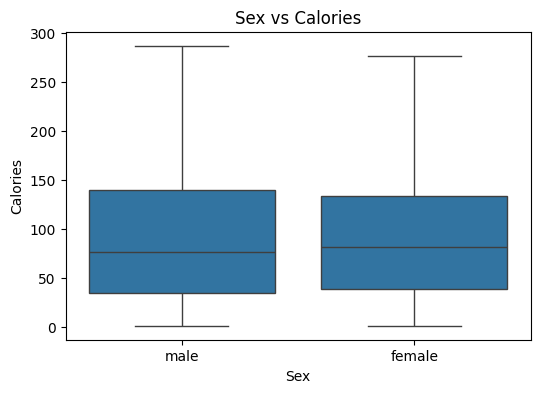

In [40]:
for col in bases.select_dtypes(include=object).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y="Calories", data=bases)
    plt.title(f"{col} vs Calories")
    plt.show()

El boxplot muestra que hombres y mujeres queman cantidades de calorías muy similares, con medianas casi iguales y rangos parecidos.No se observa una diferencia marcada entre sexos. Esto indica que, en este conjunto de datos, el sexo no influye de forma significativa en las calorías quemadas.

**Conclusiones**

La limpieza realizada permitió depurar la base de datos identificando y eliminando valores atípicos en todas las columnas numéricas mediante el método IQR, cumpliendo así el objetivo principal del proceso. Tras la depuración, las visualizaciones mostraron distribuciones más estables y relaciones más claras entre variables, logrando obtener información  más precisa. Además, la revisión por sexo reveló que las calorías quemadas no varían significativamente entre hombres y mujeres, aportando información relevante al objetivo de comprender el comportamiento general de los datos.